# Homework 02: Multi-Class Classification with Neural Networks

#### Due Date: Sunday, September 13th at 11:59pm (with 2 hour plus 1 minute grace period)

#### The late policy is described in the DX 703 Syllabus. 

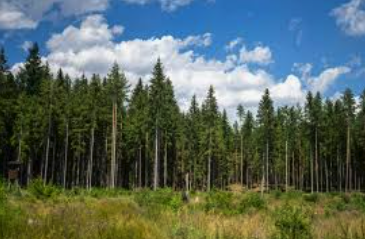

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow              import keras
from keras                  import layers

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages



import pickle


I0000 00:00:1789250823.184668    1398 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [3]:
X, y = fetch_covtype(return_X_y=True)

# Load
# X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


In [4]:
import pickle

with open(r"../data/hw2_x.pkl", 'wb') as f:
    pickle.dump(X_sub, f, protocol=pickle.HIGHEST_PROTOCOL)

with open(r"../data/hw2_y.pkl", 'wb') as f:
    pickle.dump(y_sub, f, protocol=pickle.HIGHEST_PROTOCOL)

In [5]:

# with open(r"hw2_x.pkl", 'rb') as f:
#     X_sub = pickle.load(f)

# with open(r"hw2_y.pkl", 'rb') as f:
#     y_sub = pickle.load(f)

FileNotFoundError: [Errno 2] No such file or directory: 'hw2_x.pkl'

## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [6]:
 # Perform train-test split, keeping both stratified, then standardize

# Your code here

X_train, X_test, y_train, y_test = train_test_split(
                            X_sub,
                            y_sub,
                            test_size = 0.2,
                            random_state = random_seed,
                            stratify = y_sub
)

stdscale = StandardScaler()
X_train = stdscale.fit_transform(X_train)
X_test = stdscale.transform(X_test)


### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



num col:  54
num class target:  7


I0000 00:00:1789250866.903328    1398 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6071 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2070 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/20


I0000 00:00:1789250868.875776    1809 service.cc:153] XLA service 0x7f5218030420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789250868.875814    1809 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2070 SUPER, Compute Capability 7.5 (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.25.1)
I0000 00:00:1789250868.897573    1809 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789250869.041518    1809 cuda_dnn.cc:461] Loaded cuDNN version 92501
I0000 00:00:1789250869.047740    1809 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1220__.13


 49/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1524 - loss: 2.4078

I0000 00:00:1789250870.178683    1809 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


464/481 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1729 - loss: 2.1732

I0000 00:00:1789250871.810291    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1220__.13


481/481 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1749 - loss: 2.1640
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3137 - loss: 1.7867
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4725 - loss: 1.5396
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5389 - loss: 1.3129
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5684 - loss: 1.1451
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5954 - loss: 1.0390
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6100 - loss: 0.9714
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6216 - loss: 0.9263
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6310 - loss: 0.8940
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6407 - loss: 0.8693
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6501 - loss: 0.8493
Epoch 12/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy

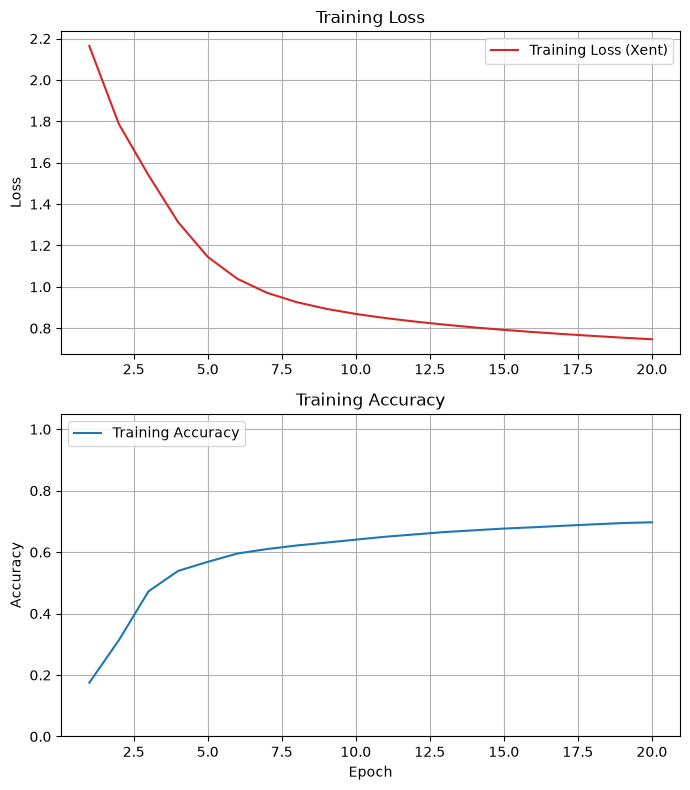

Final Training Loss:     0.7468
Final Training Accuracy: 0.6972


In [7]:
# Your code here


n_features = X_train.shape[1]
print("num col: ", n_features)

n_classes = len(np.unique(y_train))
print("num class target: ", n_classes)


model1 = keras.models.Sequential(
    [
        layers.Input(shape=(n_features, )), 
        layers.Dense(32,  activation = "relu"),
        layers.Dense(16,  activation = "relu"),
        layers.Dense(n_classes,   activation = "softmax"),
    ]
)


optimizer1 = Adam(learning_rate= 0.0001)
loss1 = 'sparse_categorical_crossentropy'
metric1 = ['accuracy']

model1.compile(optimizer= optimizer1, loss= loss1, metrics= metric1) 

#---------------
n_epoch = 20
batch1 = 32


model1_history = model1.fit(
        X_train, y_train,
        epochs = n_epoch,
        # class_weight = ..,
        batch_size = batch1,
        verbose = 1
)

print(model1_history.history['accuracy'][-1])

plot_history(model1_history)

In [8]:
# Set a1a to the final training accuracy at epoch 20

a1a = model1_history.history['accuracy'][-1]             # Replace 0.0 with your answer

In [9]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.6972


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!

In [10]:
# Your code here

def p1_model(lr):
    model = keras.Sequential([
            layers.Input(shape= (n_features,)),
            layers.Dense(32,    activation="relu"),
            layers.Dense(16,    activation="relu"),
            layers.Dense(n_classes, activation="softmax")
        ])

    model.compile(
        optimizer =     Adam(learning_rate= lr),
        loss =          "sparse_categorical_crossentropy",
        metrics =       ['accuracy']
    )

    return model


n_epoch = 20
batch_set1 = [4, 8  , 16, 128]

p2_results = []

for b in batch_set1:
    keras.backend.clear_session()
    model  = p1_model(1e-4)
    history = model.fit(
            X_train, y_train,
            epochs = n_epoch,
            batch_size = b,
            verbose = 0
    )
    p2_results.append({
        "type": 'batch sizes',
        "value": b,
        "accuracy": history.history["accuracy"][-1],
        "loss": history.history["loss"][-1]
    })

p2 = pd.DataFrame(p2_results)
display(p2)

I0000 00:00:1789250933.340919    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_41209__.13
I0000 00:00:1789250945.673577    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_41209__.13
I0000 00:00:1789251160.115533    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_350398__.13
I0000 00:00:1789251166.657858    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_350398__.13
I0000 00:00:1789251277.626630    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_505747__.13
I0000 00:00:1789251281.578912    1809 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_505747__.13
I0000 00:00:1789251343.515422    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_584216__.13
I0000 00:00:1789251345.190563    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_dat

,type,value,accuracy,loss
0,batch sizes,4,0.746408,0.608767
1,batch sizes,8,0.735747,0.637892
2,batch sizes,16,0.715270,0.686371
3,batch sizes,128,0.639212,0.896646


In [15]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = p2.loc[p2['accuracy'].idxmax(), 'value']             # Replace 0 with your answer

In [16]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [19]:
# Set a2b to the best accuracy score found

a2b = p2.sort_values('accuracy', ascending=False).iloc[0]['accuracy']            # Replace 0.0 with your answer

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7464


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.


In [ ]:
# Your code here


# def p1_model(lr):
#     model = keras.Sequential([
#         layers.Input(shape=(n_features,)),
#         layers.Dense(32, activation="relu"),
#         layers.Dense(16, activation="relu"),
#         layers.Dense(n_classes, activation="softmax")
#     ])

#     model.compile(
#         optimizer=Adam(learning_rate=lr),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

In [21]:
p3_lr = [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

def p3_run(lr_list):
    learning_rate_experiment = lr_list 
    n_ep = 20
    batch = 32

    results = []

    for lr in learning_rate_experiment:
        keras.backend.clear_session()
        model  = p1_model(lr)
        history = model.fit(
                X_train, y_train,
                epochs = n_ep,
                batch_size = batch,
                verbose = 0
        )
        results.append({
            "type": 'optimizer learning rate',
            "value": lr,
            "accuracy": history.history["accuracy"][-1],
            "loss": history.history["loss"][-1]
        })

    return pd.DataFrame(results)

# def p1_model(lr):
#     model = keras.Sequential([
#         layers.Input(shape=(n_features,)),
#         layers.Dense(32, activation="relu"),
#         layers.Dense(16, activation="relu"),
#         layers.Dense(n_classes, activation="softmax")
#     ])

#     model.compile(
#         optimizer=Adam(learning_rate=lr),
#         loss="sparse_categorical_crossentropy",
#         metrics=["accuracy"]
#     )
#     return model

p3 = p3_run(p3_lr)

display(p3)
print(p3.loc[p3['accuracy'].idxmax(), 'value'])

I0000 00:00:1789251443.509073    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_595405__.13
I0000 00:00:1789251445.882000    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_595405__.13
I0000 00:00:1789251476.973991    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_635394__.13
I0000 00:00:1789251479.222741    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_635394__.13
I0000 00:00:1789251511.863596    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_675383__.13
I0000 00:00:1789251513.986473    1810 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_675383__.13
I0000 00:00:1789251544.423223    1809 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_715372__.13
I0000 00:00:1789251546.675733    1809 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_d

,type,value,accuracy,loss
0,optimizer learning rate,0.00100,0.780602,0.532565
1,optimizer learning rate,0.00050,0.763830,0.558198
2,optimizer learning rate,0.00010,0.704544,0.713721
3,optimizer learning rate,0.00005,0.661900,0.831139
4,optimizer learning rate,0.00001,0.412013,1.566170


0.001


In [22]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = p3.loc[p3['accuracy'].idxmax(), 'value']            # Replace 0.0 with your answer

In [23]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [24]:
# Set a3b to the accuracy found by the best learning rate

a3b = p3.loc[p3['accuracy'].idxmax(), 'accuracy']            # Replace 0.0 with your answer

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.7806


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.

In [26]:
# Your code here

batch_size = 32
n_epoch = 20




init_lr = [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

def p4_run(lr):
    results = []

    for l in lr:
        keras.backend.clear_session()
        steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
        total_steps = n_epoch * steps_per_epoch
        lr_schedule = CosineDecay(
                initial_learning_rate= l,
                decay_steps=total_steps,
                alpha=0.0  # Final LR = 0
            )

        model  = p1_model(lr_schedule)
        history = model.fit(
                X_train, y_train,
                epochs = n_epoch,
                batch_size = batch_size,
                verbose = 0
        )
        results.append({
            "type": 'Cosine decay LR',
            "value": l,
            "accuracy": history.history["accuracy"][-1],
            "loss": history.history["loss"][-1]
        })

    return pd.DataFrame(results)


p4 = p4_run(init_lr) 
display(p4)
print(p4.loc[p4['accuracy'].idxmax(), 'value'])       

I0000 00:00:1789251610.247022    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_795371__.13
I0000 00:00:1789251612.551913    1811 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_795371__.13
I0000 00:00:1789251643.228336    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_835379__.13
I0000 00:00:1789251645.419533    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_835379__.13
I0000 00:00:1789251677.310085    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_875387__.13
I0000 00:00:1789251679.659264    1812 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_875387__.13
I0000 00:00:1789251711.398968    1807 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_915395__.13
I0000 00:00:1789251713.655353    1810 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_d

,type,value,accuracy,loss
0,Cosine decay LR,0.0100,0.842488,0.386332
1,Cosine decay LR,0.0050,0.832477,0.419003
2,Cosine decay LR,0.0010,0.772606,0.548494
3,Cosine decay LR,0.0005,0.744003,0.622918
4,Cosine decay LR,0.0001,0.659299,0.846068


0.01


In [27]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = p4.loc[p4['accuracy'].idxmax(), 'value']            # Replace 0.0 with your answer

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [29]:
# Set a4b to the best accuracy found

a4b = p4.loc[p4['accuracy'].idxmax(), 'accuracy']            # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8425


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

In [ ]:
# Your code here -- add as many cells as you need

p1 = pd.DataFrame([{
    "type": "baseline",
    "value": "",
    "accuracy": model1_history.history["accuracy"][-1],
    "loss": model1_history.history["loss"][-1]
}])

compare_all = pd.concat([p1, p2, p3, p4], ignore_index=True)

display(compare_all.sort_values("accuracy", ascending=False))


,type,value,accuracy,loss
10,Cosine decay LR,0.01,0.842488,0.386332
11,Cosine decay LR,0.005,0.832477,0.419003
5,optimizer learning rate,0.001,0.780602,0.532565
12,Cosine decay LR,0.001,0.772606,0.548494
6,optimizer learning rate,0.0005,0.763830,0.558198
1,batch sizes,4,0.746408,0.608767
13,Cosine decay LR,0.0005,0.744003,0.622918
2,batch sizes,8,0.735747,0.637892
3,batch sizes,16,0.715270,0.686371
7,optimizer learning rate,0.0001,0.704544,0.713721


I0000 00:00:1789252484.982441    1809 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_995411__.13
I0000 00:00:1789252487.307440    1809 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_995411__.13


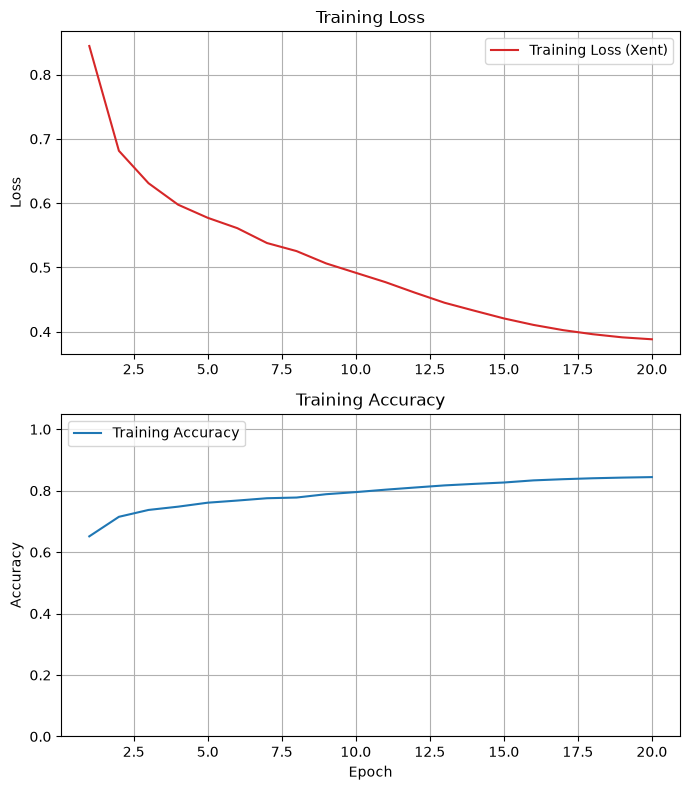

Final Training Loss:     0.3882
Final Training Accuracy: 0.8442


In [33]:
                
#      best model is cosine decay 1e-2       
# ======================================
# 
p5_batch = 32
best_learning_rate = 1e-2

keras.backend.clear_session()
p5_steps_per_epoch = int(np.ceil(len(X_train) / p5_batch))
p5_total_steps = n_epoch * p5_steps_per_epoch
p5_lr_schedule = CosineDecay(
        initial_learning_rate= best_learning_rate,
        decay_steps=p5_total_steps,
        alpha=0.0  
    )

p5_model  = p1_model(p5_lr_schedule)
p5_history = p5_model.fit(
        X_train, y_train,
        epochs = n_epoch,
        batch_size = p5_batch,
        verbose = 0
        )

plot_history(p5_history)

p5_test_loss, p5_test_accuracy = p5_model.evaluate(
    X_test, y_test,
    verbose = 0
)



In [34]:
# Set a5a to the best training accuracy found by your best model

a5a = p5_history.history["accuracy"][-1]            # Replace 0.0 with your answer

In [35]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8442


In [36]:
# Set a5b to the test accuracy found by your best model

a5b = p5_test_accuracy             # Replace 0.0 with your answer

In [37]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8157


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


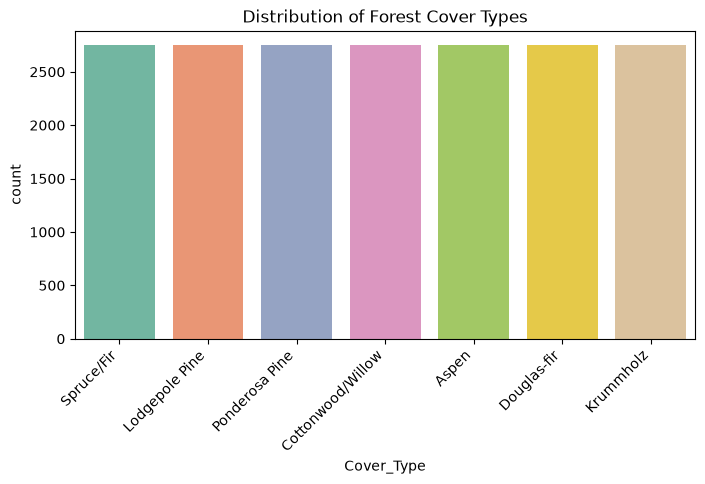

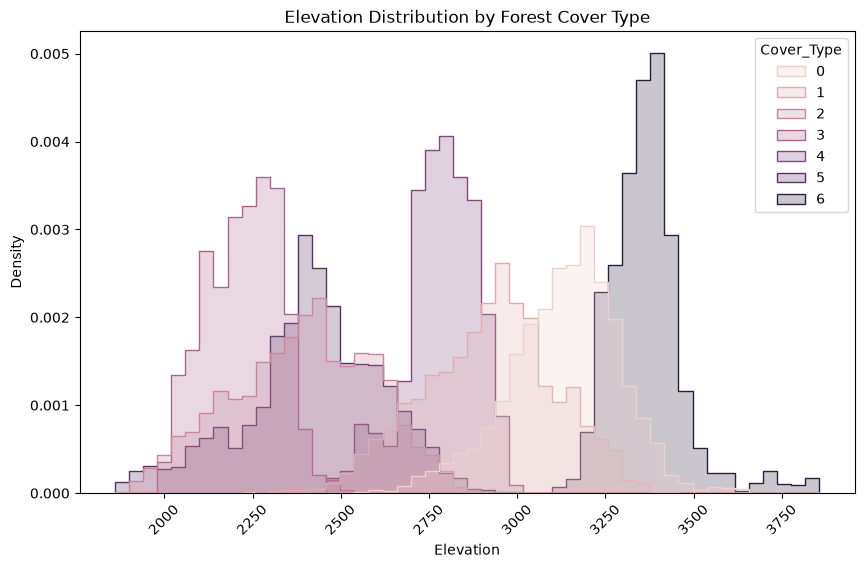

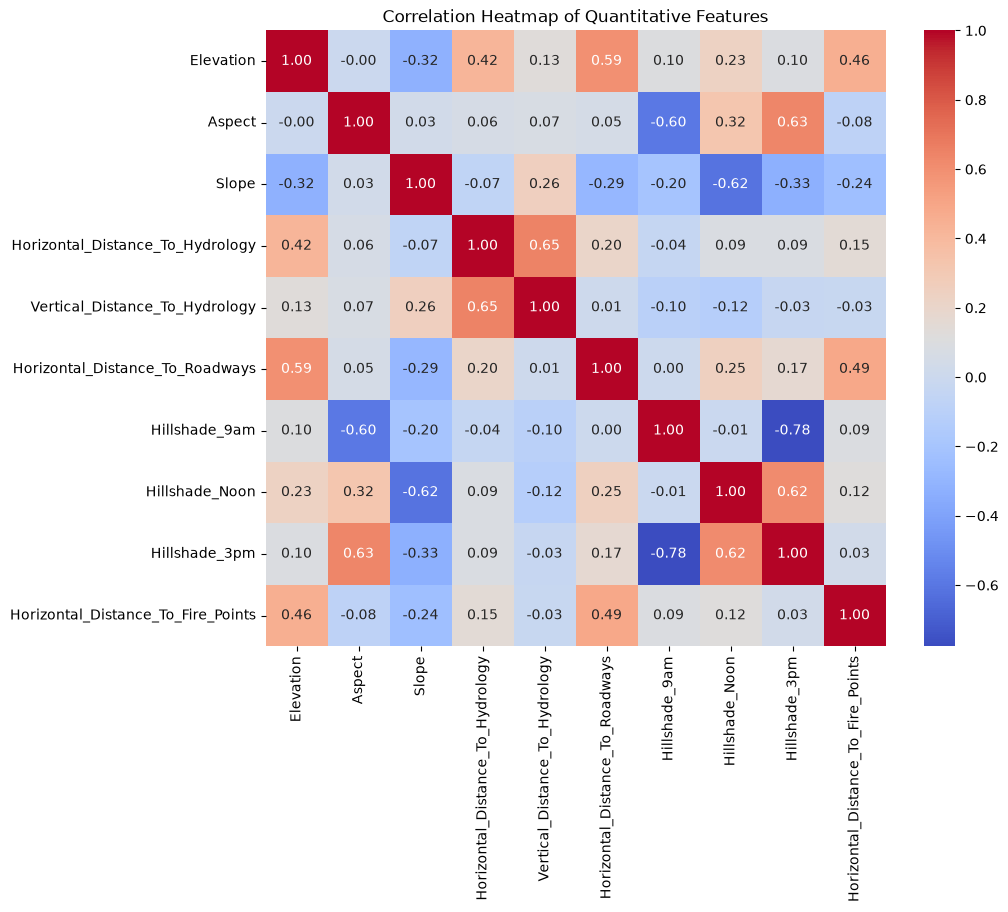

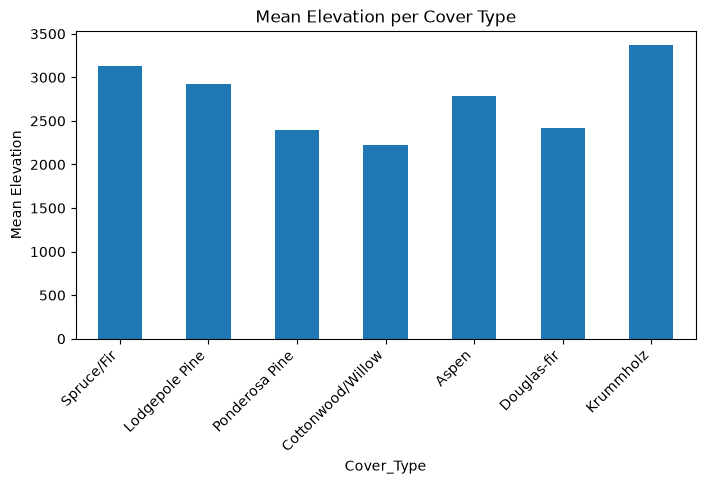

In [38]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
